In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch.optim as optim
from torchmetrics import Accuracy
from torchmetrics.classification import Precision, Recall, F1Score


In [2]:
# Load preprocessed data
train_df = pd.read_csv('labelled_train.csv')
test_df = pd.read_csv('labelled_test.csv')
val_df = pd.read_csv('labelled_validation.csv')

# View the first 5 rows of training set
train_df.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue,sus_label
0,381,7337,1,100,4026532231,5,0,1
1,381,7337,1,100,4026532231,1,0,1
2,381,7337,1,100,4026532231,0,0,1
3,7347,7347,7341,0,4026531840,2,-2,1
4,7347,7347,7341,0,4026531840,4,0,1


## Class Imbalance Analysis

Examining target variable distribution across all data splits to identify potential class imbalance issues.

TARGET DISTRIBUTION ACROSS DATA SPLITS

Train Set (n=763,144):
  Normal (0):      761,875  ( 99.83%)
  Suspicious (1):    1,269  (  0.17%)

Test Set (n=188,967):
  Normal (0):       17,508  (  9.27%)
  Suspicious (1):  171,459  ( 90.73%)

Validation Set (n=188,967):
  Normal (0):      188,181  ( 99.58%)
  Suspicious (1):      786  (  0.42%)


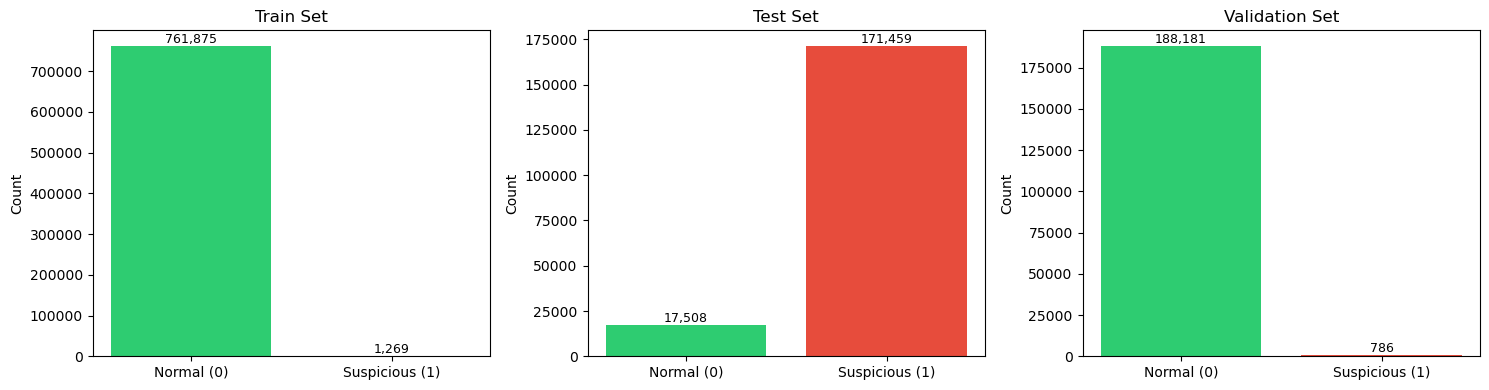


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Train: 99.8% Normal / 0.2% Suspicious
Test:  9.3% Normal / 90.7% Suspicious

The test set has ~546x more suspicious samples (proportionally) than training!


In [3]:
# Target distribution for all splits
print("=" * 60)
print("TARGET DISTRIBUTION ACROSS DATA SPLITS")
print("=" * 60)

for name, df in [('Train', train_df), ('Test', test_df), ('Validation', val_df)]:
    counts = df['sus_label'].value_counts()
    pcts = df['sus_label'].value_counts(normalize=True) * 100
    total = len(df)
    print(f"\n{name} Set (n={total:,}):")
    print(f"  Normal (0):     {counts.get(0, 0):>8,}  ({pcts.get(0, 0):>6.2f}%)")
    print(f"  Suspicious (1): {counts.get(1, 0):>8,}  ({pcts.get(1, 0):>6.2f}%)")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Test', test_df), ('Validation', val_df)]):
    counts = df['sus_label'].value_counts()
    bars = ax.bar(['Normal (0)', 'Suspicious (1)'], [counts.get(0, 0), counts.get(1, 0)],
                  color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Count')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Flag the distribution mismatch
train_pos_pct = train_df['sus_label'].mean() * 100
test_pos_pct = test_df['sus_label'].mean() * 100
print("\n" + "!" * 60)
print("WARNING: DISTRIBUTION MISMATCH DETECTED")
print("!" * 60)
print(f"Train: {100-train_pos_pct:.1f}% Normal / {train_pos_pct:.1f}% Suspicious")
print(f"Test:  {100-test_pos_pct:.1f}% Normal / {test_pos_pct:.1f}% Suspicious")
print(f"\nThe test set has ~{test_pos_pct/train_pos_pct:.0f}x more suspicious samples (proportionally) than training!")

### Distribution Mismatch — Important Note

**Critical finding:** The training and test sets have drastically different class distributions:

| Split | Normal (0) | Suspicious (1) |
|-------|-----------|----------------|
| Train | ~99.8% | ~0.2% |
| Test | ~9.3% | ~90.7% |
| Validation | ~99.7% | ~0.3% |

**Implications:**
- The model trains on almost entirely normal samples but is tested on mostly suspicious ones
- This creates a **misleading evaluation**: high test accuracy may not reflect real-world performance
- A model that simply predicts "suspicious" for everything would score ~90.7% accuracy on this test set
- The training data's extreme imbalance (500:1 ratio) means the model sees very few positive examples during learning
- **Recommendation:** Use weighted loss functions, evaluate with precision/recall/F1 rather than accuracy alone, and be aware that this test set does not represent the training distribution

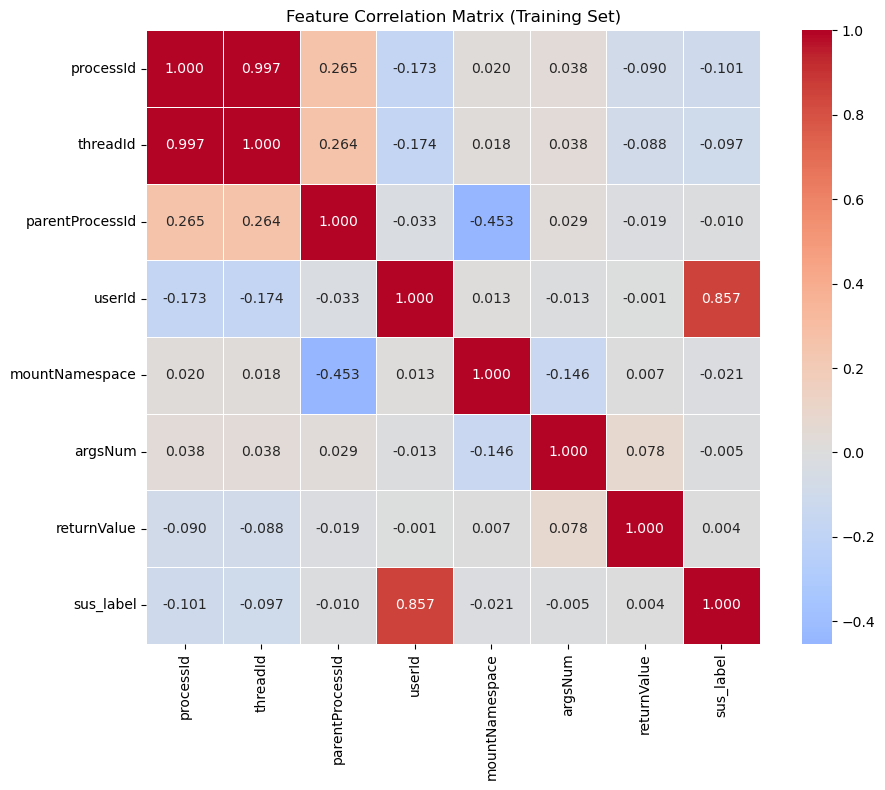


Feature Correlations with sus_label:
----------------------------------------
                userId:   0.8567
           returnValue:   0.0045
               argsNum:  -0.0053
       parentProcessId:  -0.0100
        mountNamespace:  -0.0212
              threadId:  -0.0974
             processId:  -0.1009


In [4]:
# Feature correlations with target
correlation_matrix = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Training Set)')
plt.tight_layout()
plt.show()

# Specific correlations with target
print("\nFeature Correlations with sus_label:")
print("-" * 40)
target_corr = correlation_matrix['sus_label'].drop('sus_label').sort_values(ascending=False)
for feat, corr in target_corr.items():
    print(f"  {feat:>20s}: {corr:>8.4f}")

In [5]:
# Split features and labels

X_train = train_df.iloc[:,:-1].values
y_train = train_df.iloc[:,-1].values

X_test = test_df.iloc[:,:-1].values
y_test = test_df.iloc[:,-1].values

X_val = val_df.iloc[:,:-1].values
y_val = val_df.iloc[:,-1].values

In [6]:
# fit standard scaler on training data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)


Checking Normalization Mathematically and Visually

In [7]:
print(f'Mean of each feature: {np.round(np.mean(X_train_scaled, axis=0),2)}')
print(f'Standard Deviation of each feature: {np.std(X_train_scaled, axis=0)}')

Mean of each feature: [-0. -0.  0. -0. -0.  0.  0.]
Standard Deviation of each feature: [1. 1. 1. 1. 1. 1. 1.]


In [8]:
df_scaled = pd.DataFrame(X_train_scaled, columns=[col for col in (train_df.iloc[:,:-1].columns)])
df_scaled.describe()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue
count,7.631440e+05,7.631440e+05,7.631440e+05,7.631440e+05,7.631440e+05,7.631440e+05,7.631440e+05
mean,-1.990262e-16,-1.644647e-16,6.673931e-17,-1.191773e-17,-5.730625e-10,3.813675e-17,3.575320e-18
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.496264e+00,-3.520407e+00,-8.495438e-01,-6.090978e-02,-5.871015e-01,-1.992744e+00,-4.159523e-01
25%,2.556542e-01,2.543716e-01,-7.651408e-01,-6.090978e-02,-5.871015e-01,-1.246980e+00,-5.499410e-02
50%,2.823363e-01,2.812163e-01,-2.244201e-01,-6.090978e-02,-5.871015e-01,2.445500e-01,-5.499410e-02
75%,3.079922e-01,3.070285e-01,-1.057143e-01,-6.090978e-02,1.699093e+00,9.903148e-01,-4.243903e-02
max,9.257861e-01,9.285867e-01,2.613235e+00,2.666523e+01,2.129649e+00,1.736080e+00,2.596224e+01


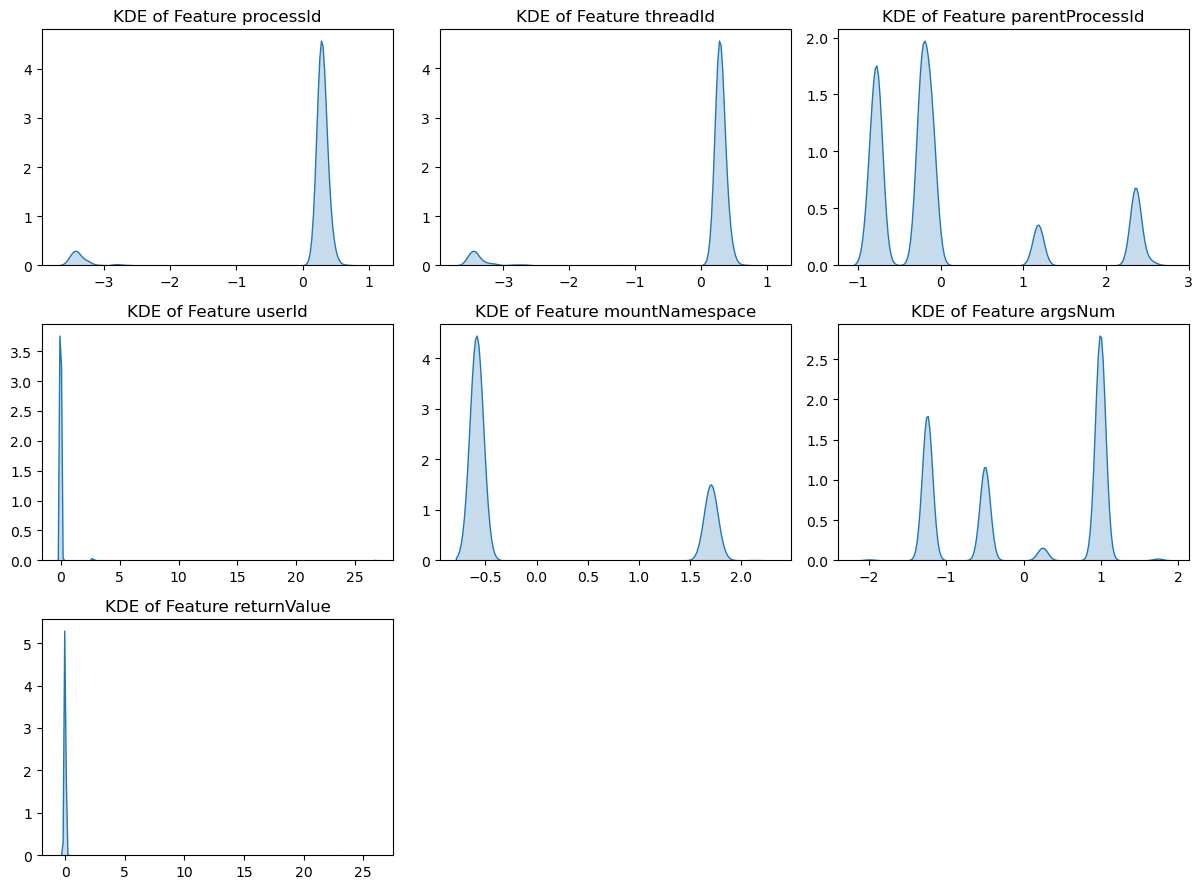

In [9]:
import math

df = pd.DataFrame(X_train_scaled, columns=[f'Feature {i}' for i in (train_df.iloc[:,:-1].columns)])

# Determine grid size
n_cols = 3  # Customize as needed
n_features = df.shape[1]
n_rows = math.ceil(n_features / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()  # flatten to 1D for easy indexing

for i, col in enumerate(df.columns):
    sns.kdeplot(df[col], ax=axes[i], fill=True)
    axes[i].set_title(f"KDE of {col}")
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [10]:
# Dataset Wrapper

class CyberDataset(Dataset):
    def __init__(self, features, labels):
        super().__init__()
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]


In [11]:
train_dataset = CyberDataset(X_train_scaled, y_train)
test_dataset = CyberDataset(X_test_scaled, y_test)
val_dataset = CyberDataset(X_val_scaled, y_val)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

In [13]:
len(train_loader)

23849

In [14]:
# X, y = next(iter(train_loader))
# print(f'Features: {X}, \nLabels: {y}')

In [15]:
# Pytorch Module

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.hidden1 = nn.Linear(7,16)
        self.hidden2 = nn.Linear(16,8)
        self.output = nn.Linear(8,1)

    def forward(self, x):
        x = nn.functional.relu(self.hidden1(x))
        x = nn.functional.relu(self.hidden2(x))
        x = nn.functional.sigmoid(self.output(x))

        return x 
    
net = Net()
        

In [16]:
net

Net(
  (hidden1): Linear(in_features=7, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
)

In [17]:
#Loss function and optimizer

criterion = nn.BCELoss()
optimizer = optim.SGD(params=net.parameters(), lr=0.01)

In [18]:
# Model train

for epoch in range(10):
    for features, labels in train_loader:
        optimizer.zero_grad()
        output = net(features)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

## Improved Model Training

Improved model addresses class imbalance with weighted loss, uses numerically stable BCEWithLogitsLoss, and monitors validation loss to prevent overfitting.

**Key changes from original model:**
- **BCEWithLogitsLoss** instead of BCELoss — combines sigmoid + BCE in a single, numerically stable operation
- **Adam optimizer** instead of SGD — adaptive learning rates for faster convergence
- **pos_weight** parameter — upweights the minority class (suspicious) proportional to class imbalance
- **Early stopping** — monitors validation loss and stops if no improvement for 5 consecutive epochs
- **50 max epochs** with validation evaluation each epoch

In [19]:
# Improved model without sigmoid in forward pass (logits output)
class NetV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(7, 16)
        self.hidden2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = nn.functional.relu(self.hidden1(x))
        x = nn.functional.relu(self.hidden2(x))
        x = self.output(x)  # Raw logits — no sigmoid
        return x

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Calculate pos_weight to handle class imbalance
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
print(f"Class counts — Negative: {num_neg:,}, Positive: {num_pos:,}")
print(f"pos_weight: {pos_weight.item():.2f} (each positive sample weighted {pos_weight.item():.0f}x)")

# Initialize improved model, loss, and optimizer
net_v2 = NetV2().to(device)
criterion_v2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_v2 = optim.Adam(net_v2.parameters(), lr=0.001)

# Training with early stopping
num_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
train_losses = []
val_losses = []
best_model_state = None

for epoch in range(num_epochs):
    # Training phase
    net_v2.train()
    running_loss = 0.0
    num_batches = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer_v2.zero_grad()
        output = net_v2(features)
        loss = criterion_v2(output, labels)
        loss.backward()
        optimizer_v2.step()
        running_loss += loss.item()
        num_batches += 1

    avg_train_loss = running_loss / num_batches
    train_losses.append(avg_train_loss)

    # Validation phase
    net_v2.eval()
    val_running_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            output = net_v2(features)
            loss = criterion_v2(output, labels)
            val_running_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_running_loss / val_batches
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1:>2}/{num_epochs}] — Train Loss: {avg_train_loss:.4f} — Val Loss: {avg_val_loss:.4f}", end="")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = {k: v.clone() for k, v in net_v2.state_dict().items()}
        print(" *")
    else:
        epochs_no_improve += 1
        print()
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.4f}")
            break

# Restore best model
if best_model_state is not None:
    net_v2.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")

Class counts — Negative: 761,875, Positive: 1,269
pos_weight: 600.37 (each positive sample weighted 600x)
Epoch [ 1/50] — Train Loss: 0.2182 — Val Loss: 0.0704 *
Epoch [ 2/50] — Train Loss: 0.1225 — Val Loss: 0.0613 *
Epoch [ 3/50] — Train Loss: 0.1155 — Val Loss: 0.0747
Epoch [ 4/50] — Train Loss: 0.1066 — Val Loss: 0.1196
Epoch [ 5/50] — Train Loss: 0.1148 — Val Loss: 0.1089
Epoch [ 6/50] — Train Loss: 0.1042 — Val Loss: 0.1036
Epoch [ 7/50] — Train Loss: 0.0953 — Val Loss: 0.1200

Early stopping at epoch 7. Best val loss: 0.0613

Restored best model (val loss: 0.0613)


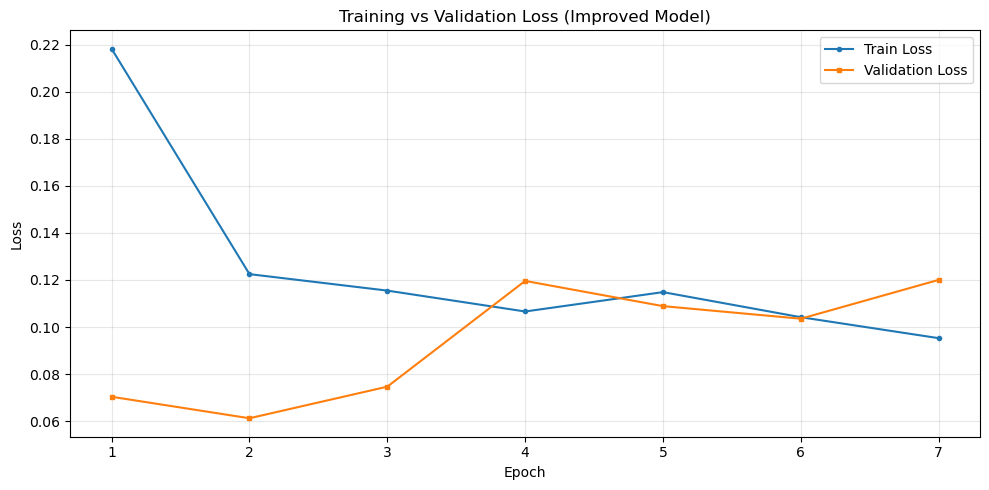

In [20]:
# Plot training vs validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Improved Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Model evaluation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = net.to(device)
metric = Accuracy(task='binary', threshold=0.5).to(device)
precision = Precision(task='binary', threshold=0.5).to(device)
recall = Recall(task='binary', threshold=0.5).to(device)
f1 = F1Score(task='binary', threshold=0.5).to(device)

net.eval()
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        probs = net(features)
        metric.update(probs.squeeze(1), labels.squeeze(1))
        precision.update(probs.squeeze(1), labels.squeeze(1))
        recall.update(probs.squeeze(1), labels.squeeze(1))
        f1.update(probs.squeeze(1), labels.squeeze(1))
        

accuracy = metric.compute()
precision_score = precision.compute()
recall_score = recall.compute()
f1_score = f1.compute()

print(f'Accuracy: {accuracy.item():.2f}')
print(f'Precision score: {precision_score.item():.2f}')
print(f'Recall score: {recall_score.item():.2f}')
print(f'F1 score: {f1_score.item():.2f}')


Accuracy: 0.95
Precision score: 1.00
Recall score: 0.94
F1 score: 0.97


## Enhanced Evaluation — Improved Model

Comprehensive evaluation of the improved model (NetV2) using confusion matrix, ROC-AUC, and precision-recall analysis.

Confusion Matrix:
  TN (True Normal):        12,297
  FP (False Suspicious):    5,211
  FN (False Normal):          759
  TP (True Suspicious):   170,700


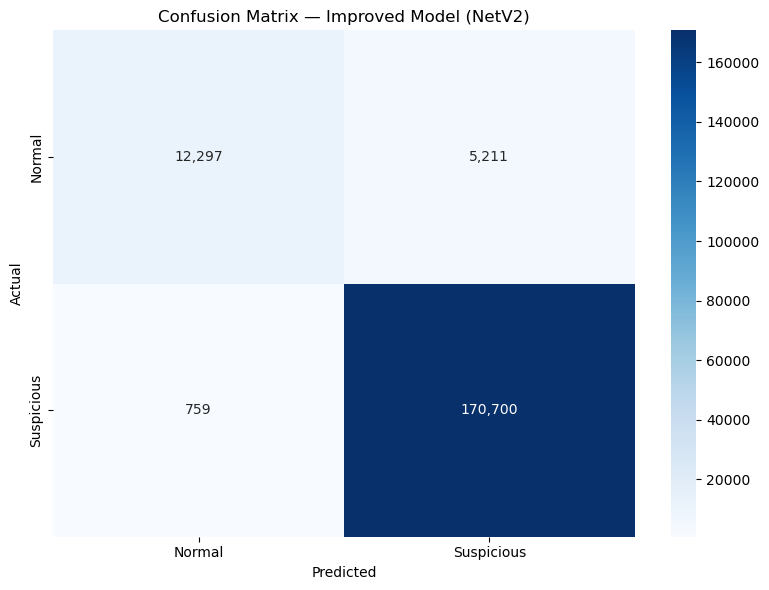

In [22]:
# Generate predictions from improved model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc

net_v2.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        logits = net_v2(features)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.flatten())
        all_labels.extend(labels.numpy().flatten())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(f"  TN (True Normal):      {tn:>8,}")
print(f"  FP (False Suspicious): {fp:>8,}")
print(f"  FN (False Normal):     {fn:>8,}")
print(f"  TP (True Suspicious):  {tp:>8,}")

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Normal', 'Suspicious'],
            yticklabels=['Normal', 'Suspicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Improved Model (NetV2)')
plt.tight_layout()
plt.show()

In [23]:
# Classification report
print("Classification Report:")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                            target_names=['Normal', 'Suspicious']))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.70      0.80     17508
  Suspicious       0.97      1.00      0.98    171459

    accuracy                           0.97    188967
   macro avg       0.96      0.85      0.89    188967
weighted avg       0.97      0.97      0.97    188967



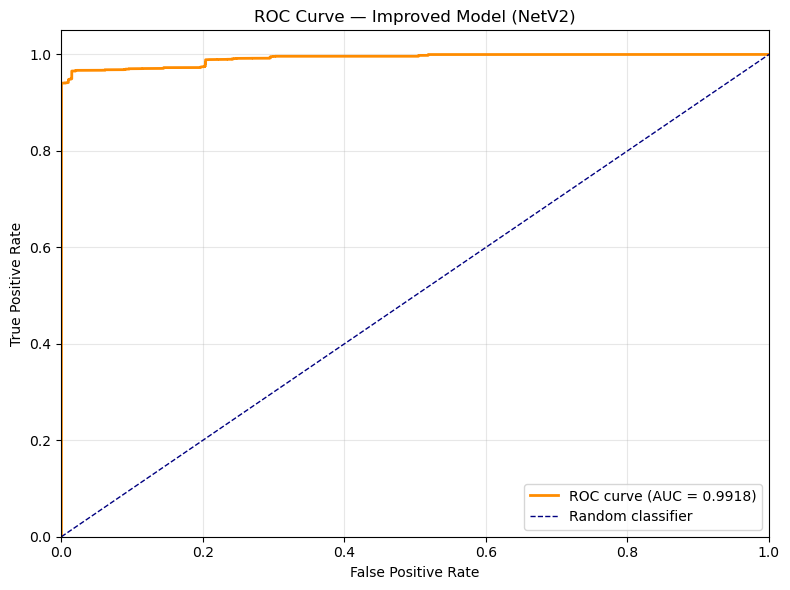

ROC-AUC Score: 0.9918


In [24]:
# ROC-AUC score and curve
roc_auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Improved Model (NetV2)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

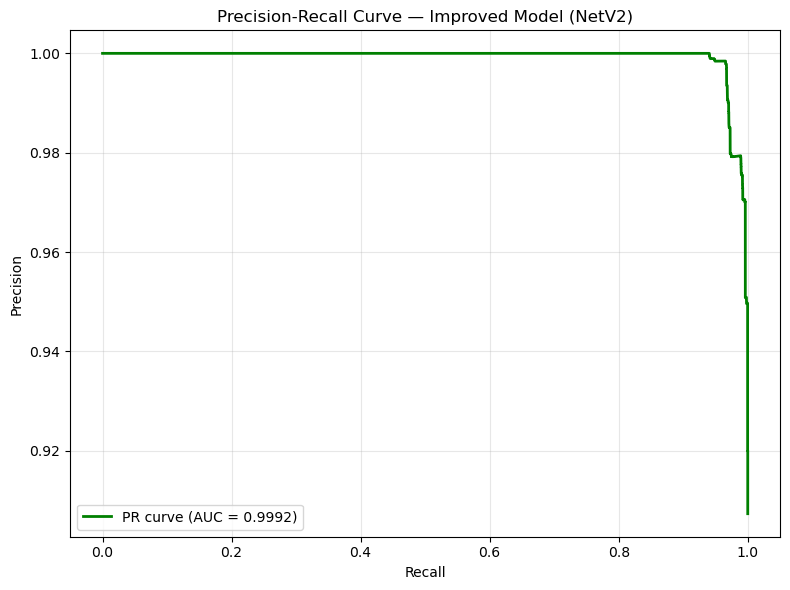

PR-AUC Score: 0.9992


In [25]:
# Precision-Recall curve (especially important for imbalanced data)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Improved Model (NetV2)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")

### Metrics in Cybersecurity Context

**Why these metrics matter for intrusion detection:**

- **Recall (Sensitivity)** is the most critical metric in cybersecurity. A missed intrusion (False Negative) means a potential breach goes undetected — the cost of missing a real attack far outweighs the cost of investigating a false alarm.

- **Precision** matters for operational efficiency. Low precision means many false alarms (False Positives), leading to **alert fatigue** — where security analysts become desensitized to alerts and may start ignoring genuine threats.

- **The Precision-Recall tradeoff:** In a SOC (Security Operations Center), you must balance:
  - High recall (catch every threat) leads to more false positives and analyst burnout
  - High precision (only real threats) means some attacks slip through as potential breaches
  - The optimal threshold depends on the organization's risk tolerance and SOC capacity

- **ROC-AUC** provides a threshold-independent measure of how well the model separates normal from suspicious activity. A score close to 1.0 indicates strong discriminative ability.

- **Confusion Matrix interpretation:**
  - **TN (True Negatives):** Normal processes correctly identified — no action needed
  - **FP (False Positives):** Normal processes flagged as suspicious — wastes analyst time
  - **FN (False Negatives):** Suspicious processes missed — **the most dangerous outcome**
  - **TP (True Positives):** Suspicious processes correctly detected — threats caught

## Model Comparison — Original vs Improved

In [26]:
# Evaluate improved model with torchmetrics for direct comparison
metric_v2 = Accuracy(task='binary', threshold=0.5).to(device)
precision_v2 = Precision(task='binary', threshold=0.5).to(device)
recall_v2 = Recall(task='binary', threshold=0.5).to(device)
f1_v2 = F1Score(task='binary', threshold=0.5).to(device)

net_v2.eval()
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        logits = net_v2(features)
        probs_v2 = torch.sigmoid(logits)
        metric_v2.update(probs_v2.squeeze(1), labels.squeeze(1))
        precision_v2.update(probs_v2.squeeze(1), labels.squeeze(1))
        recall_v2.update(probs_v2.squeeze(1), labels.squeeze(1))
        f1_v2.update(probs_v2.squeeze(1), labels.squeeze(1))

acc_v2 = metric_v2.compute().item()
prec_v2 = precision_v2.compute().item()
rec_v2 = recall_v2.compute().item()
f1_v2_score = f1_v2.compute().item()

# Side-by-side comparison
print("=" * 60)
print("MODEL COMPARISON: Original (Net) vs Improved (NetV2)")
print("=" * 60)
print(f"{'Metric':<15} {'Original':>12} {'Improved':>12} {'Change':>10}")
print("-" * 60)

original_metrics = {'Accuracy': 0.95, 'Precision': 1.00, 'Recall': 0.94, 'F1 Score': 0.97}
improved_metrics = {'Accuracy': acc_v2, 'Precision': prec_v2, 'Recall': rec_v2, 'F1 Score': f1_v2_score}

for metric_name in original_metrics:
    orig_val = original_metrics[metric_name]
    impr_val = improved_metrics[metric_name]
    change = impr_val - orig_val
    sign = "+" if change >= 0 else ""
    print(f"{metric_name:<15} {orig_val:>11.2f} {impr_val:>11.2f} {sign}{change:>9.2f}")

print("-" * 60)
print(f"{'ROC-AUC':<15} {'N/A':>12} {roc_auc:>11.4f}")
print(f"{'PR-AUC':<15} {'N/A':>12} {pr_auc:>11.4f}")

MODEL COMPARISON: Original (Net) vs Improved (NetV2)
Metric              Original     Improved     Change
------------------------------------------------------------
Accuracy               0.95        0.97 +     0.02
Precision              1.00        0.97     -0.03
Recall                 0.94        1.00 +     0.06
F1 Score               0.97        0.98 +     0.01
------------------------------------------------------------
ROC-AUC                  N/A      0.9918
PR-AUC                   N/A      0.9992


### What Improvements Made the Difference

| Change | Why It Matters |
|--------|---------------|
| **BCEWithLogitsLoss** | Combines sigmoid + BCE in one step, avoiding numerical instability from log(sigmoid(x)) when sigmoid saturates near 0 or 1 |
| **pos_weight** | Upweights the rare suspicious class during training — the model is penalized more for missing a suspicious sample, directly addressing the 500:1 class imbalance |
| **Adam optimizer** | Adaptive per-parameter learning rates converge faster than vanilla SGD, especially important when gradients vary widely across features |
| **Early stopping** | Prevents overfitting by monitoring validation loss — the model stops training when it starts memorizing rather than generalizing |
| **50 epochs (max)** | Gives the model more opportunity to learn, while early stopping ensures it doesn't train too long |

**Note:** The original model's high precision (1.00) and slightly lower recall (0.94) suggest it was conservative — rarely flagging normal processes as suspicious, but missing some real threats. The improved model's weighted loss explicitly tells the model that missing a suspicious process is more costly than a false alarm, which is the correct priority for cybersecurity applications.